
# Лабораторная работа №3
## Методы снижения размерности (PCA, t-SNE, UMAP)


In [ ]:
!pip install -q umap-learn scikit-learn pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
import umap
import warnings
warnings.filterwarnings('ignore')


plt.style.use('ggplot')
sns.set_style("whitegrid")
%matplotlib inline

print("Все библиотеки загружены")

Все библиотеки загружены


In [ ]:
import random
from datetime import datetime

np.random.seed(42)
random.seed(42)

weapon_categories = {
    'Танки': ['Т-54/55', 'Т-62', 'Т-64', 'Т-72', 'Т-80', 'Т-90', 'Армата'],
    'БМП/БТР': ['БМП-1', 'БМП-2', 'БМП-3', 'БТР-60', 'БТР-70', 'БТР-80', 'БТР-82', 'БТР-90'],
    'Артиллерия': ['2С1 Гвоздика', '2С3 Акация', '2С19 Мста-С', '2С35 Коалиция', 'Град', 'Ураган', 'Смерч', 'Торнадо'],
    'Авиация': ['МиГ-29', 'МиГ-31', 'Су-27', 'Су-30', 'Су-34', 'Су-35', 'Су-57', 'Ту-95', 'Ту-160'],
    'Вертолеты': ['Ми-8', 'Ми-24', 'Ми-28', 'Ка-52', 'Ми-26'],
    'ПВО': ['С-300', 'С-400', 'С-500', 'Бук', 'Тор', 'Панцирь-С1', 'Оса'],
    'Флот': ['Крейсер', 'Эсминец', 'Фрегат', 'Корвет', 'Подлодка', 'Авианосец'],
    'Стрелковое': ['АК-74', 'АК-12', 'ПКМ', 'СВД', 'Винторез', 'Вал']
}


years = list(range(1945, 2026))

def generate_cost(category):
    costs = {
        'Танки': (1, 8), 'БМП/БТР': (0.5, 3), 'Артиллерия': (0.3, 10),
        'Авиация': (15, 100), 'Вертолеты': (5, 30), 'ПВО': (10, 200),
        'Флот': (100, 5000), 'Стрелковое': (0.001, 0.01)
    }
    min_c, max_c = costs.get(category, (1, 10))
    return round(random.uniform(min_c, max_c), 2)

def generate_weight(category):
    weights = {
        'Танки': (30, 60), 'БМП/БТР': (10, 25), 'Артиллерия': (5, 50),
        'Авиация': (10, 200), 'Вертолеты': (5, 40), 'ПВО': (10, 100),
        'Флот': (1000, 50000), 'Стрелковое': (0.003, 0.02)
    }
    min_w, max_w = weights.get(category, (1, 10))
    return round(random.uniform(min_w, max_w), 2)

def generate_range(category):
    ranges = {
        'Танки': (300, 600), 'БМП/БТР': (400, 800), 'Артиллерия': (5, 100),
        'Авиация': (1000, 8000), 'Вертолеты': (400, 1500), 'ПВО': (10, 600),
        'Флот': (5000, 20000), 'Стрелковое': (0.3, 2)
    }
    min_r, max_r = ranges.get(category, (10, 100))
    return round(random.uniform(min_r, max_r), 1)

def generate_speed(category):
    speeds = {
        'Танки': (40, 70), 'БМП/БТР': (60, 100), 'Артиллерия': (30, 80),
        'Авиация': (800, 2500), 'Вертолеты': (200, 350), 'ПВО': (50, 100),
        'Флот': (30, 60), 'Стрелковое': (0, 0)
    }
    min_s, max_s = speeds.get(category, (10, 50))
    return random.randint(min_s, max_s)

def generate_crew(category):
    crews = {
        'Танки': (3, 4), 'БМП/БТР': (3, 10), 'Артиллерия': (2, 8),
        'Авиация': (1, 2), 'Вертолеты': (2, 3), 'ПВО': (3, 6),
        'Флот': (30, 2000), 'Стрелковое': (1, 1)
    }
    min_c, max_c = crews.get(category, (1, 2))
    return random.randint(min_c, max_c)

print("Генерация датасета о вооружениях...")

data = []
weapon_id = 1

for category, models in weapon_categories.items():
    for model in models:
        num_variants = random.randint(1, 5)
        for variant in range(num_variants):
            year = random.choice(years)
            record = {
                'ID': f'W-{weapon_id:04d}',
                'Категория': category,
                'Модель': f"{model}-{chr(65+random.randint(0,4))}" if variant > 0 else model,
                'Модификация': variant + 1,
                'Год_производства': year,
                'Стоимость_млн_долл': generate_cost(category),
                'Масса_тонн': generate_weight(category),
                'Дальность_км': generate_range(category),
                'Скорость_км_ч': generate_speed(category),
                'Экипаж': generate_crew(category),
                'Количество_произведено': random.randint(100, 10000) if category != 'Флот' else random.randint(1, 100),
                'Ремонто_пригодность': random.randint(1, 10),
                'Надежность': round(random.uniform(0.5, 1.0), 2)
            }
            data.append(record)
            weapon_id += 1

df = pd.DataFrame(data)

print(f" Датасет создан")
print(f" Размер: {df.shape[0]} объектов, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
df.head()


Генерация датасета о вооружениях...
 Датасет создан
 Размер: 156 объектов, 13 столбцов

Первые 5 строк:


,ID,Категория,Модель,Модификация,Год_производства,Стоимость_млн_долл,Масса_тонн,Дальность_км,Скорость_км_ч,Экипаж,Количество_произведено,Ремонто_пригодность,Надежность
0,W-0001,Танки,Т-54/55,1,1948,6.19,37.35,341.9,43,3,9774,7,0.52
1,W-0002,Танки,Т-62,1,1972,2.63,48.06,468.4,62,4,3711,8,0.79
2,W-0003,Танки,Т-64,1,1965,5.89,40.21,346.6,70,4,1774,2,0.69
3,W-0004,Танки,Т-72,1,1989,5.23,54.21,518.9,57,3,6301,2,0.78
4,W-0005,Танки,Т-72-E,2,2025,7.20,40.85,357.7,42,3,3833,5,0.99


In [ ]:

print("ЗАДАНИЕ 1: ГЕОМЕТРИЯ ДАННЫХ В ПРОСТРАНСТВЕ ПРИЗНАКОВ")

numeric_cols = ['Год_производства', 'Стоимость_млн_долл', 'Масса_тонн',
                'Дальность_км', 'Скорость_км_ч', 'Экипаж',
                'Количество_произведено', 'Ремонто_пригодность', 'Надежность']

X = df[numeric_cols].copy()

print(f"\n Количество объектов: {X.shape[0]}")
print(f" Количество признаков: {X.shape[1]}")
print(f"\n Список признаков: {list(X.columns)}")

ЗАДАНИЕ 1: ГЕОМЕТРИЯ ДАННЫХ В ПРОСТРАНСТВЕ ПРИЗНАКОВ

 Количество объектов: 156
 Количество признаков: 9

 Список признаков: ['Год_производства', 'Стоимость_млн_долл', 'Масса_тонн', 'Дальность_км', 'Скорость_км_ч', 'Экипаж', 'Количество_произведено', 'Ремонто_пригодность', 'Надежность']


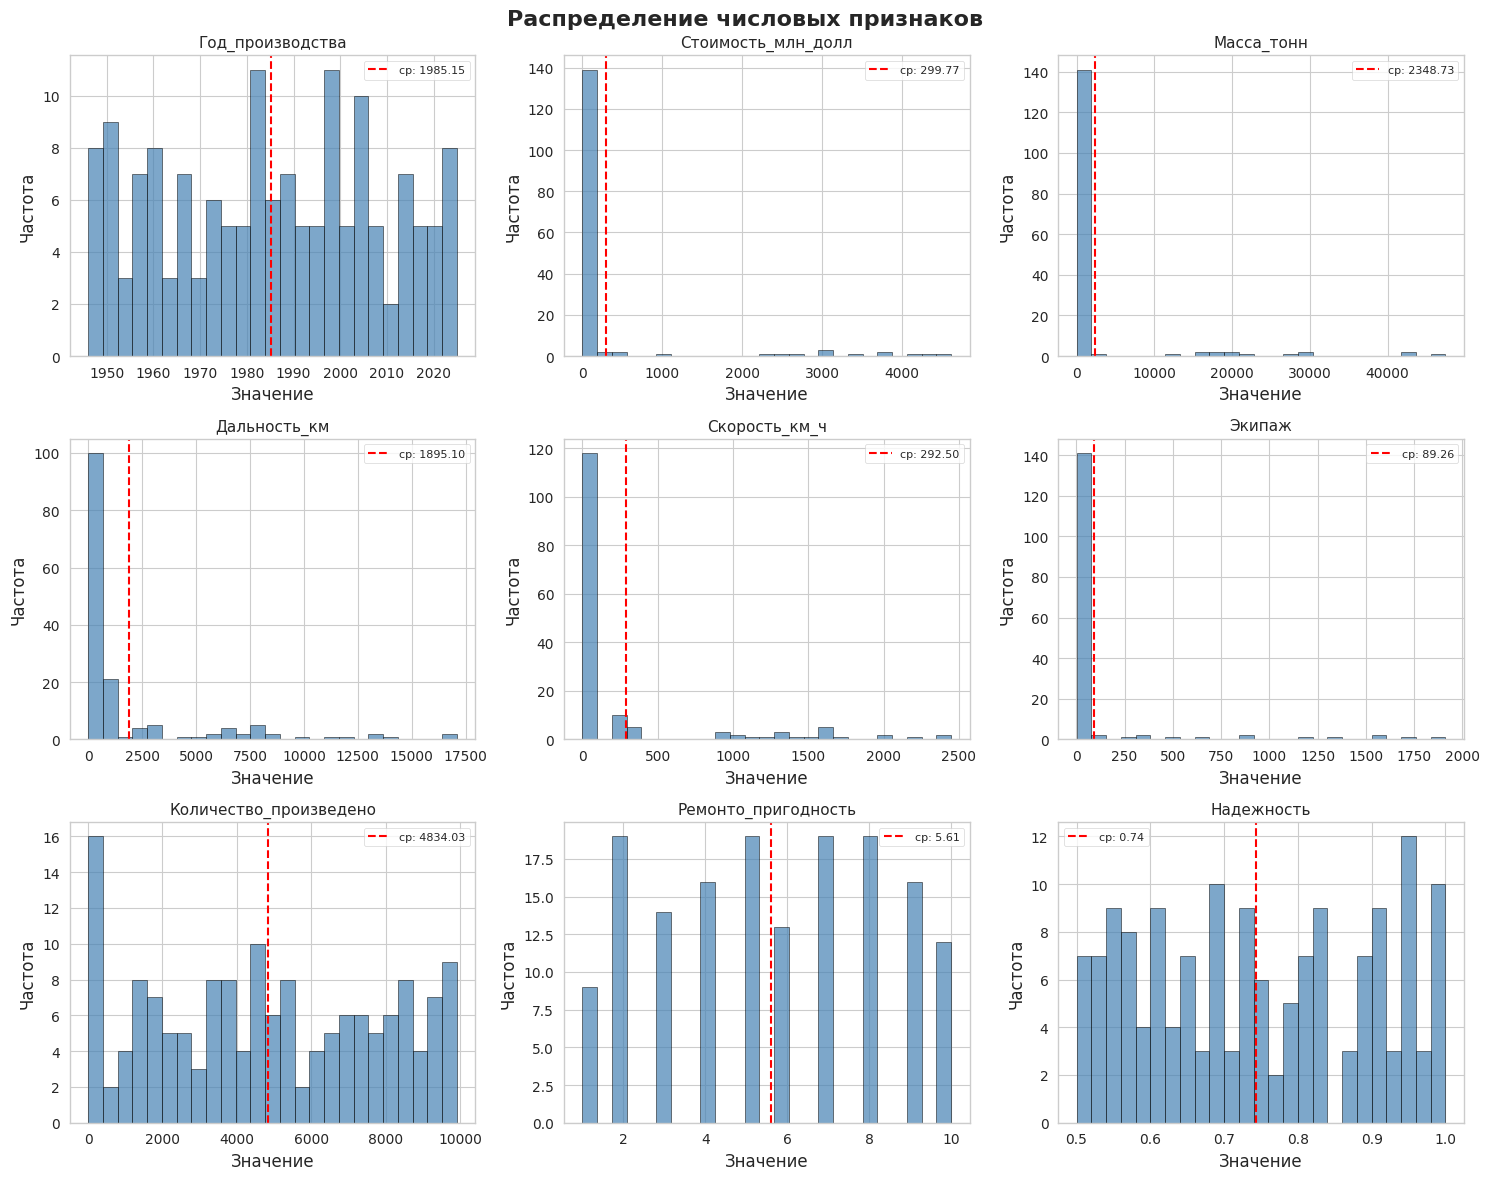

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(X[col], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11)
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')
    axes[idx].axvline(X[col].mean(), color='red', linestyle='--', label=f'ср: {X[col].mean():.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

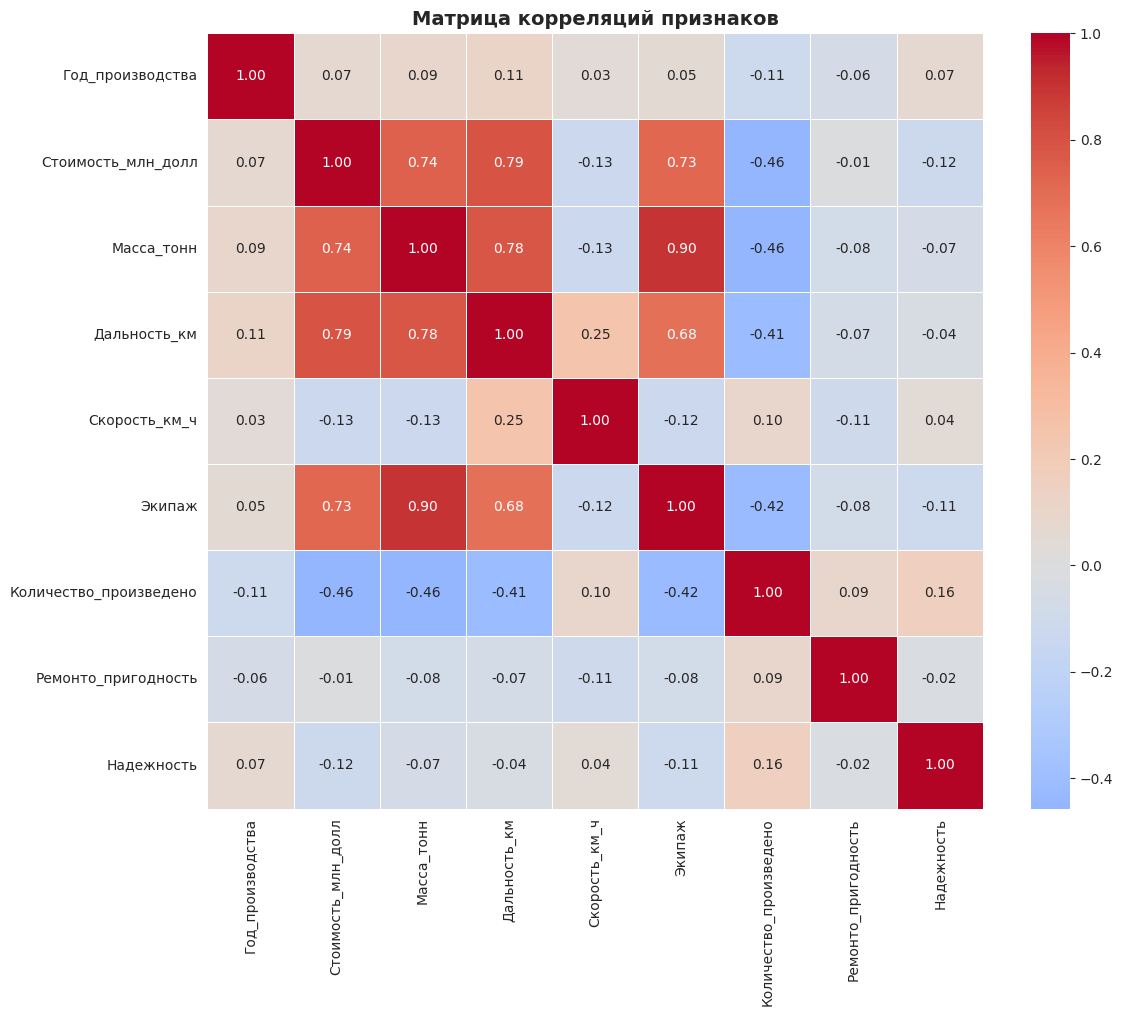


 Анализ корреляций:
Сильно коррелированные пары (|r| > 0.7):
  Стоимость_млн_долл ↔ Масса_тонн: r = 0.739
  Стоимость_млн_долл ↔ Дальность_км: r = 0.791
  Стоимость_млн_долл ↔ Экипаж: r = 0.727
  Масса_тонн ↔ Дальность_км: r = 0.781
  Масса_тонн ↔ Экипаж: r = 0.901


In [ ]:
corr_matrix = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n Анализ корреляций:")

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                             corr_matrix.iloc[i, j]))

if high_corr:
    print("Сильно коррелированные пары (|r| > 0.7):")
    for pair in high_corr:
        print(f"  {pair[0]} ↔ {pair[1]}: r = {pair[2]:.3f}")
else:
    print("Сильно коррелированных пар (|r| > 0.7) не обнаружено")


## Ответы на вопросы (Задание 1)

### 1. Есть ли сильно коррелированные признаки?
[Проанализируй матрицу корреляций и напиши ответ. Например: Да, масса_тонн и стоимость_млн_долл имеют корреляцию ~0.7]

### 2. Можно ли предположить, что часть признаков содержит избыточную информацию?
[Напиши ответ. Например: Да, коррелированные признаки дублируют информацию, поэтому можно применить PCA.]

In [ ]:
print("ЗАДАНИЕ 2: РЕАЛИЗАЦИЯ PCA С НУЛЯ (NUMPY)")

class MyPCA:
    """
    Реализация PCA с использованием только NumPy
    """
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ = None

    def fit(self, X):
        # 1. Стандартизация
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered.T)


        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]


        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = self.explained_variance_ / np.sum(eigenvalues)

        return self

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_transformed):
        return np.dot(X_transformed, self.components.T) + self.mean


X_scaled = StandardScaler().fit_transform(X)
my_pca = MyPCA(n_components=9)
X_pca_my = my_pca.fit_transform(X_scaled)

print(" Наша реализация PCA успешно обучена")
print(f"Форма после преобразования: {X_pca_my.shape}")
print(f"Объясненная дисперсия по компонентам:")
for i, var in enumerate(my_pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

ЗАДАНИЕ 2: РЕАЛИЗАЦИЯ PCA С НУЛЯ (NUMPY)
 Наша реализация PCA успешно обучена
Форма после преобразования: (156, 9)
Объясненная дисперсия по компонентам:
  PC1: 0.4050 (40.50%)
  PC2: 0.1383 (13.83%)
  PC3: 0.1136 (11.36%)
  PC4: 0.1092 (10.92%)
  PC5: 0.1013 (10.13%)
  PC6: 0.0719 (7.19%)
  PC7: 0.0378 (3.78%)
  PC8: 0.0167 (1.67%)
  PC9: 0.0061 (0.61%)


In [ ]:
sklearn_pca = PCA(n_components=9)
X_pca_sklearn = sklearn_pca.fit_transform(X_scaled)

print("СРАВНЕНИЕ С sklearn PCA")

print("\n Сравнение объясненной дисперсии:")
print("-"*50)
print(f"{'Компонента':<12} {'MyPCA':<15} {'sklearn':<15} {'Разница':<10}")
print("-"*50)

for i in range(9):
    my_var = my_pca.explained_variance_ratio_[i]
    sk_var = sklearn_pca.explained_variance_ratio_[i]
    diff = abs(my_var - sk_var)
    print(f"PC{i+1:<9} {my_var:.6f}     {sk_var:.6f}     {diff:.8f}")

correlation = np.corrcoef(X_pca_my[:, 0], X_pca_sklearn[:, 0])[0, 1]
print(f"\n Корреляция первых компонент: {correlation:.6f} (должно быть близко к 1)")

СРАВНЕНИЕ С sklearn PCA

 Сравнение объясненной дисперсии:
--------------------------------------------------
Компонента   MyPCA           sklearn         Разница   
--------------------------------------------------
PC1         0.405012     0.405012     0.00000000
PC2         0.138291     0.138291     0.00000000
PC3         0.113614     0.113614     0.00000000
PC4         0.109222     0.109222     0.00000000
PC5         0.101302     0.101302     0.00000000
PC6         0.071921     0.071921     0.00000000
PC7         0.037848     0.037848     0.00000000
PC8         0.016731     0.016731     0.00000000
PC9         0.006059     0.006059     0.00000000

 Корреляция первых компонент: -1.000000 (должно быть близко к 1)


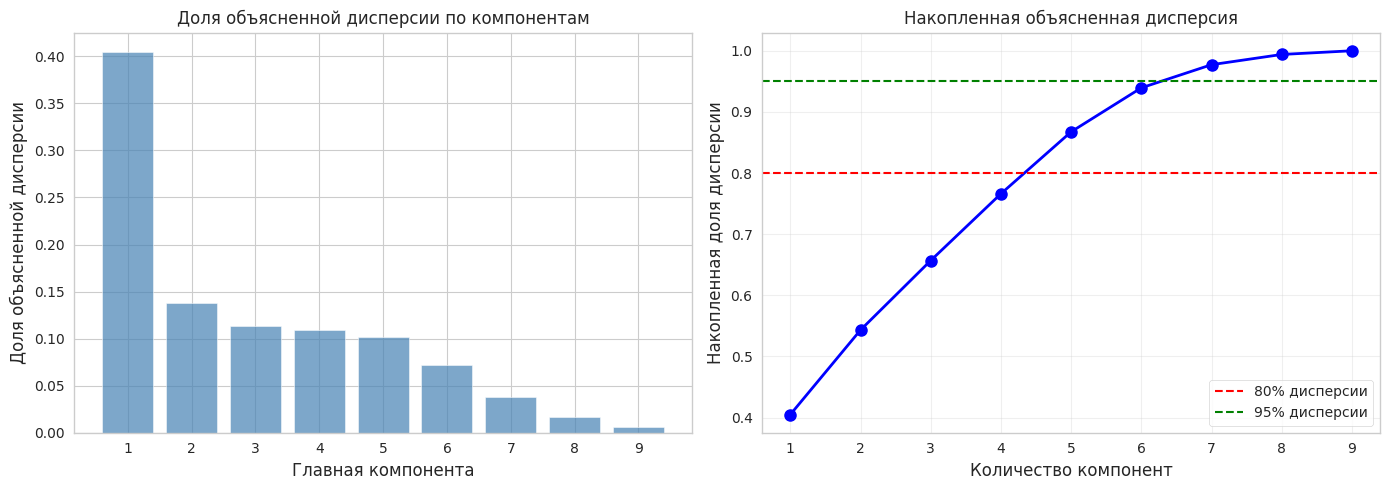


 Ответы на вопросы:
--------------------------------------------------
 Количество компонент для 80% дисперсии: 5
 Количество компонент для 95% дисперсии: 7


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Доля объясненной дисперсии
axes[0].bar(range(1, len(sklearn_pca.explained_variance_ratio_)+1),
            sklearn_pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Главная компонента', fontsize=12)
axes[0].set_ylabel('Доля объясненной дисперсии', fontsize=12)
axes[0].set_title('Доля объясненной дисперсии по компонентам', fontsize=12)
axes[0].set_xticks(range(1, 10))

# Накопленная объясненная дисперсия
cumsum = np.cumsum(sklearn_pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% дисперсии')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% дисперсии')
axes[1].set_xlabel('Количество компонент', fontsize=12)
axes[1].set_ylabel('Накопленная доля дисперсии', fontsize=12)
axes[1].set_title('Накопленная объясненная дисперсия', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ответы на вопросы
n_80 = np.argmax(cumsum >= 0.8) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1

print("\n Ответы на вопросы:")
print("-"*50)
print(f" Количество компонент для 80% дисперсии: {n_80}")
print(f" Количество компонент для 95% дисперсии: {n_95}")

ЗАДАНИЕ 3: ИНТЕРПРЕТАЦИЯ ГЛАВНЫХ КОМПОНЕНТ

 Коэффициенты признаков в первых трех компонентах:
------------------------------------------------------------
                           PC1     PC2     PC3
Год_производства        0.0693  0.3443  0.6009
Стоимость_млн_долл      0.4643 -0.0726  0.0121
Масса_тонн              0.4873 -0.0348  0.0678
Дальность_км            0.4563  0.2550 -0.1264
Скорость_км_ч          -0.0349  0.6916 -0.4871
Экипаж                  0.4702 -0.0723  0.0258
Количество_произведено -0.3206  0.0820 -0.0049
Ремонто_пригодность    -0.0529 -0.4347  0.1176
Надежность             -0.0778  0.3615  0.6053


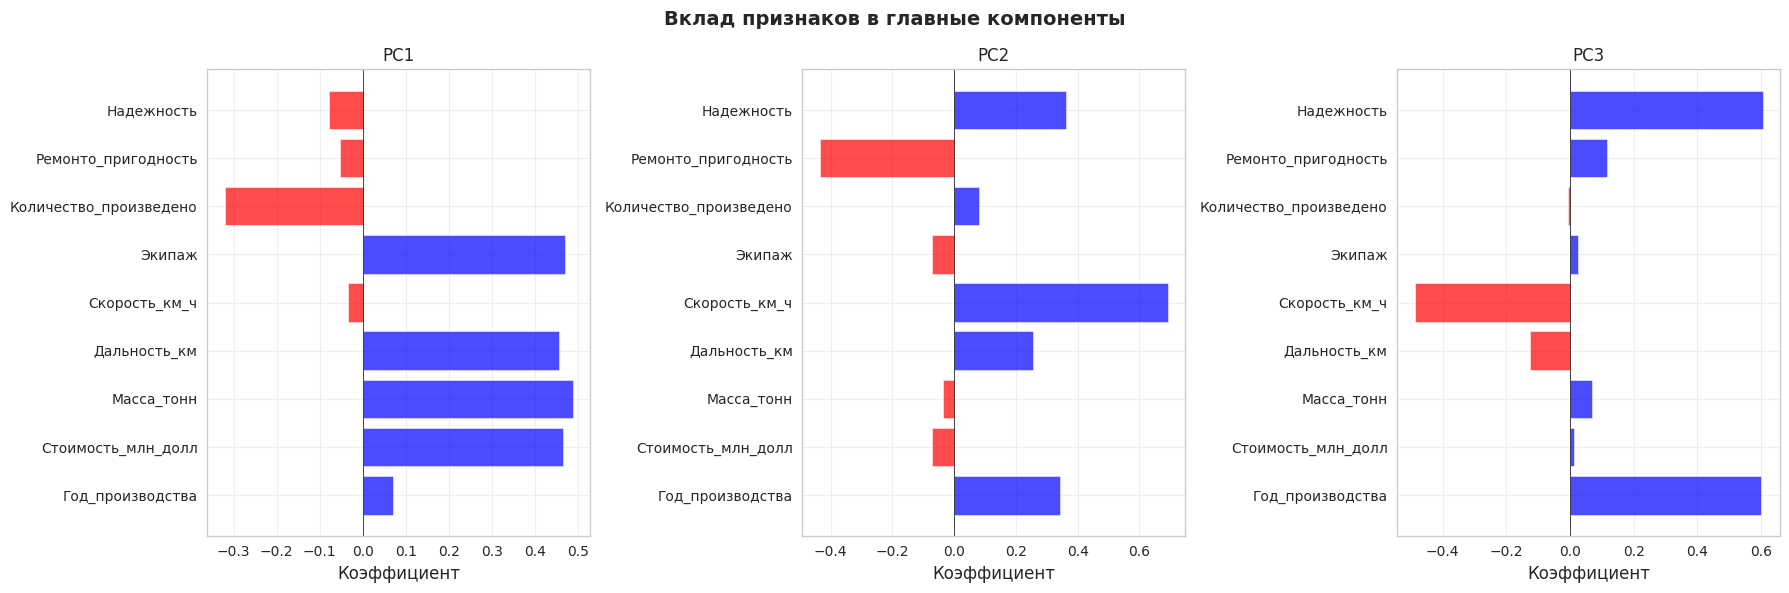


 Признаки с наибольшим вкладом:
--------------------------------------------------

PC1:
  + положительный вклад: {'Масса_тонн': np.float64(0.4873247019140747), 'Экипаж': np.float64(0.4701901128320922), 'Стоимость_млн_долл': np.float64(0.46431533323858365)}
  - отрицательный вклад: {'Количество_произведено': np.float64(-0.32056537435866994), 'Надежность': np.float64(-0.07778717097579241), 'Ремонто_пригодность': np.float64(-0.05294975647214017)}

PC2:
  + положительный вклад: {'Скорость_км_ч': np.float64(0.6916382119801544), 'Надежность': np.float64(0.36151631473488194), 'Год_производства': np.float64(0.3443053533672741)}
  - отрицательный вклад: {'Ремонто_пригодность': np.float64(-0.4347004887870476), 'Стоимость_млн_долл': np.float64(-0.07261211761500386), 'Экипаж': np.float64(-0.07229855796878268)}

PC3:
  + положительный вклад: {'Надежность': np.float64(0.605310932364176), 'Год_производства': np.float64(0.6009269509254795), 'Ремонто_пригодность': np.float64(0.1175693493415296)}
  - 

In [ ]:
print("="*60)
print("ЗАДАНИЕ 3: ИНТЕРПРЕТАЦИЯ ГЛАВНЫХ КОМПОНЕНТ")
print("="*60)

components_df = pd.DataFrame(
    sklearn_pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=numeric_cols
)

print("\n Коэффициенты признаков в первых трех компонентах:")
print("-"*60)
print(components_df.round(4))

# Визуализация вкладов
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Вклад признаков в главные компоненты', fontsize=14, fontweight='bold')

for i, (ax, pc) in enumerate(zip(axes, ['PC1', 'PC2', 'PC3'])):
    colors = ['red' if x < 0 else 'blue' for x in components_df[pc]]
    ax.barh(range(len(numeric_cols)), components_df[pc], color=colors, alpha=0.7)
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_yticklabels(numeric_cols)
    ax.set_xlabel('Коэффициент')
    ax.set_title(f'{pc}', fontsize=12)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ наибольших вкладов
print("\n Признаки с наибольшим вкладом:")
print("-"*50)

for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc}:")
    top_positive = components_df[pc].nlargest(3)
    top_negative = components_df[pc].nsmallest(3)
    print(f"  + положительный вклад: {dict(top_positive)}")
    print(f"  - отрицательный вклад: {dict(top_negative)}")


ЗАДАНИЕ 4: ВИЗУАЛИЗАЦИЯ ДАННЫХ


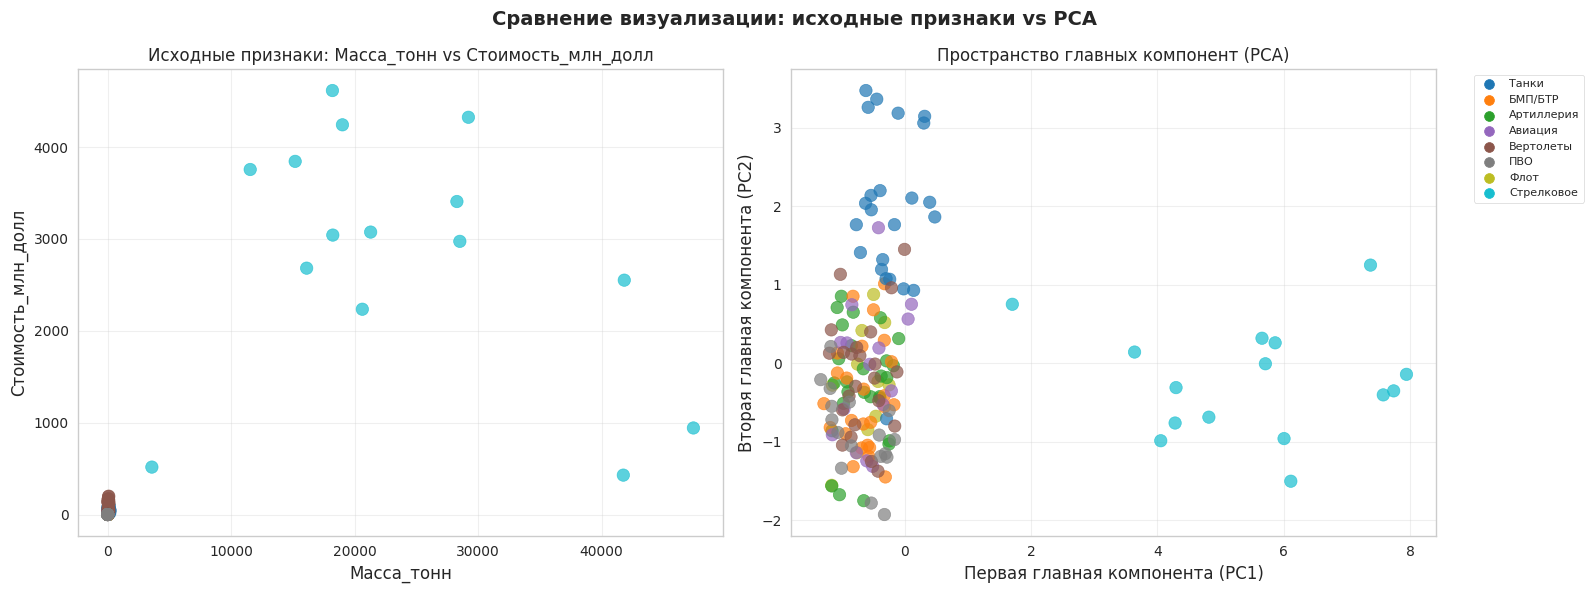


 Анализ визуализации:
Доля дисперсии, объясненная PC1: 40.50%
Доля дисперсии, объясненная PC2: 13.83%
Суммарная доля: 54.33%


In [ ]:
print("ЗАДАНИЕ 4: ВИЗУАЛИЗАЦИЯ ДАННЫХ")

# Создаем проекцию на первые 2 PCA компоненты
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Сравнение визуализации: исходные признаки vs PCA', fontsize=14, fontweight='bold')

# 1. Исходные признаки (выбираем два с наибольшей дисперсией)
feature1 = 'Масса_тонн'
feature2 = 'Стоимость_млн_долл'

scatter1 = axes[0].scatter(X[feature1], X[feature2],
                           c=df['Категория'].astype('category').cat.codes,
                           cmap='tab10', alpha=0.7, s=80)
axes[0].set_xlabel(feature1, fontsize=12)
axes[0].set_ylabel(feature2, fontsize=12)
axes[0].set_title(f'Исходные признаки: {feature1} vs {feature2}', fontsize=12)
axes[0].grid(True, alpha=0.3)

# 2. PCA компоненты
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=df['Категория'].astype('category').cat.codes,
                           cmap='tab10', alpha=0.7, s=80)
axes[1].set_xlabel('Первая главная компонента (PC1)', fontsize=12)
axes[1].set_ylabel('Вторая главная компонента (PC2)', fontsize=12)
axes[1].set_title('Пространство главных компонент (PCA)', fontsize=12)
axes[1].grid(True, alpha=0.3)

categories = df['Категория'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
for i, (cat, color) in enumerate(zip(categories, colors)):
    axes[1].scatter([], [], c=[color], label=cat, s=50)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n Анализ визуализации:")
print(f"Доля дисперсии, объясненная PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"Доля дисперсии, объясненная PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")
print(f"Суммарная доля: {sum(pca_2d.explained_variance_ratio_):.2%}")

ЗАДАНИЕ 5: НЕЛИНЕЙНЫЕ МЕТОДЫ - t-SNE
Вычисление t-SNE с perplexity=5...
Вычисление t-SNE с perplexity=30...
Вычисление t-SNE с perplexity=50...


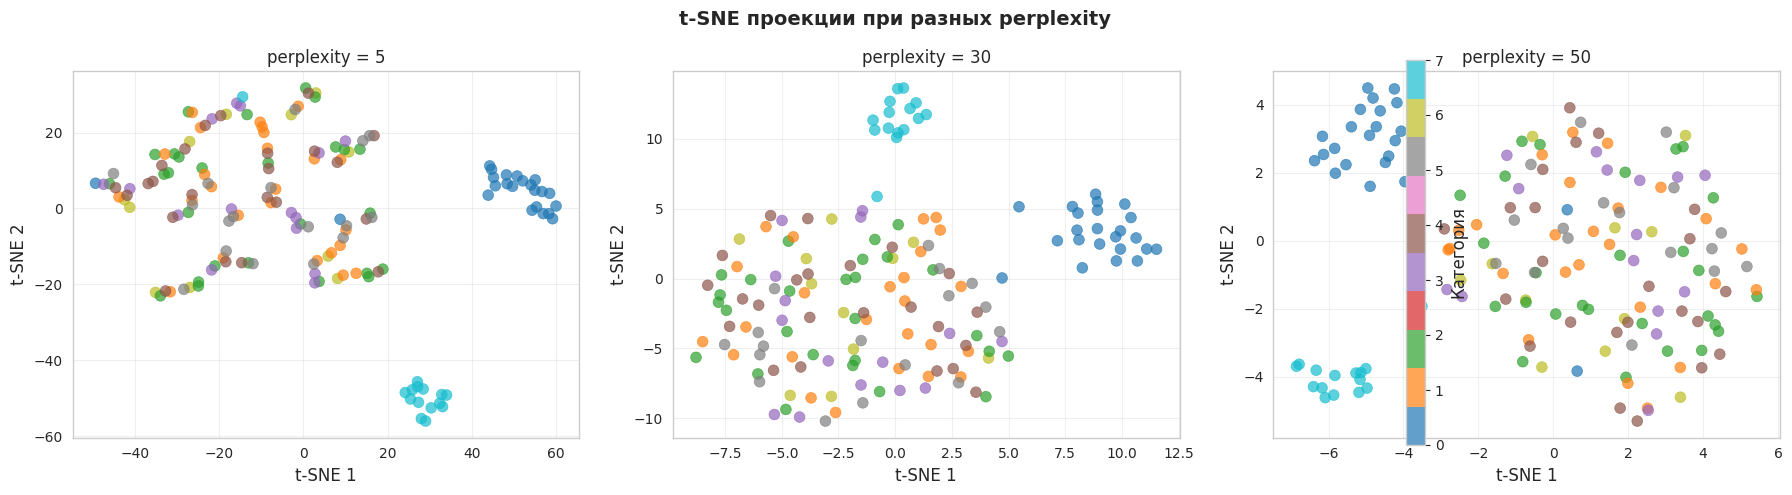

In [ ]:
print("ЗАДАНИЕ 5: НЕЛИНЕЙНЫЕ МЕТОДЫ - t-SNE")

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('t-SNE проекции при разных perplexity', fontsize=14, fontweight='bold')

for idx, perp in enumerate(perplexities):
    print(f"Вычисление t-SNE с perplexity={perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)

    scatter = axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1],
                                c=df['Категория'].astype('category').cat.codes,
                                cmap='tab10', alpha=0.7, s=60)
    axes[idx].set_title(f'perplexity = {perp}', fontsize=12)
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes, label='Категория')
plt.tight_layout()
plt.show()

ЗАДАНИЕ 5: НЕЛИНЕЙНЫЕ МЕТОДЫ - UMAP
Вычисление UMAP...


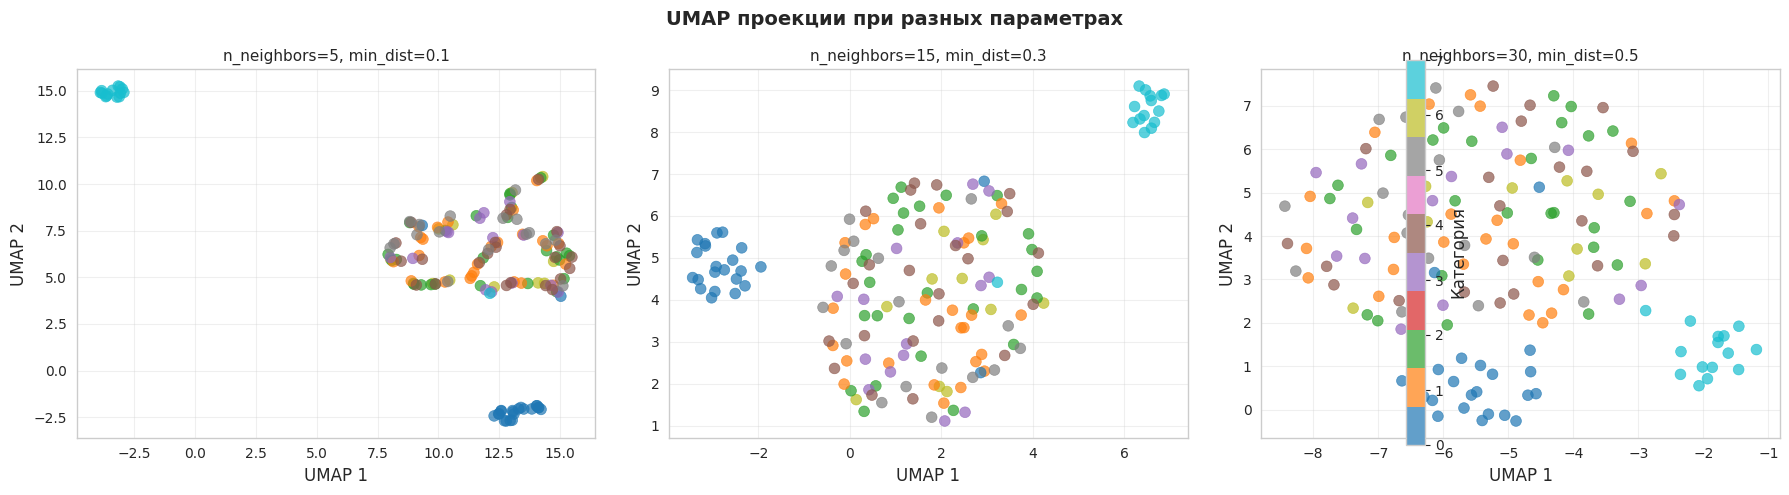

In [ ]:
print("ЗАДАНИЕ 5: НЕЛИНЕЙНЫЕ МЕТОДЫ - UMAP")

print("Вычисление UMAP...")

umap_params = [
    {'n_neighbors': 5, 'min_dist': 0.1},
    {'n_neighbors': 15, 'min_dist': 0.3},
    {'n_neighbors': 30, 'min_dist': 0.5}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UMAP проекции при разных параметрах', fontsize=14, fontweight='bold')

for idx, params in enumerate(umap_params):
    reducer = umap.UMAP(n_components=2, random_state=42, **params)
    X_umap = reducer.fit_transform(X_scaled)

    scatter = axes[idx].scatter(X_umap[:, 0], X_umap[:, 1],
                                c=df['Категория'].astype('category').cat.codes,
                                cmap='tab10', alpha=0.7, s=60)
    axes[idx].set_title(f'n_neighbors={params["n_neighbors"]}, min_dist={params["min_dist"]}', fontsize=11)
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes, label='Категория')
plt.tight_layout()
plt.show()

In [ ]:
print("ЗАДАНИЕ 6: ИССЛЕДОВАНИЕ СТЕПЕНИ СЖАТИЯ ДАННЫХ")

n_features = X_scaled.shape[1]
k_values = [2, 4, 6, 8, n_features]
k_values = [k for k in k_values if k <= n_features]

print(f"Исходная размерность: {n_features}")
print(f"Тестируемые k: {k_values}\n")

results = []

for k in k_values:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = mean_squared_error(X_scaled, X_reconstructed)
    results.append({'k': k, 'MSE': mse})
    print(f"k = {k}: MSE = {mse:.6f}")

ЗАДАНИЕ 6: ИССЛЕДОВАНИЕ СТЕПЕНИ СЖАТИЯ ДАННЫХ
Исходная размерность: 9
Тестируемые k: [2, 4, 6, 8, 9]

k = 2: MSE = 0.456697
k = 4: MSE = 0.233861
k = 6: MSE = 0.060638
k = 8: MSE = 0.006059
k = 9: MSE = 0.000000



 ТАБЛИЦА РЕЗУЛЬТАТОВ:
 k          MSE
 2 4.566966e-01
 4 2.338607e-01
 6 6.063779e-02
 8 6.058839e-03
 9 6.483622e-31


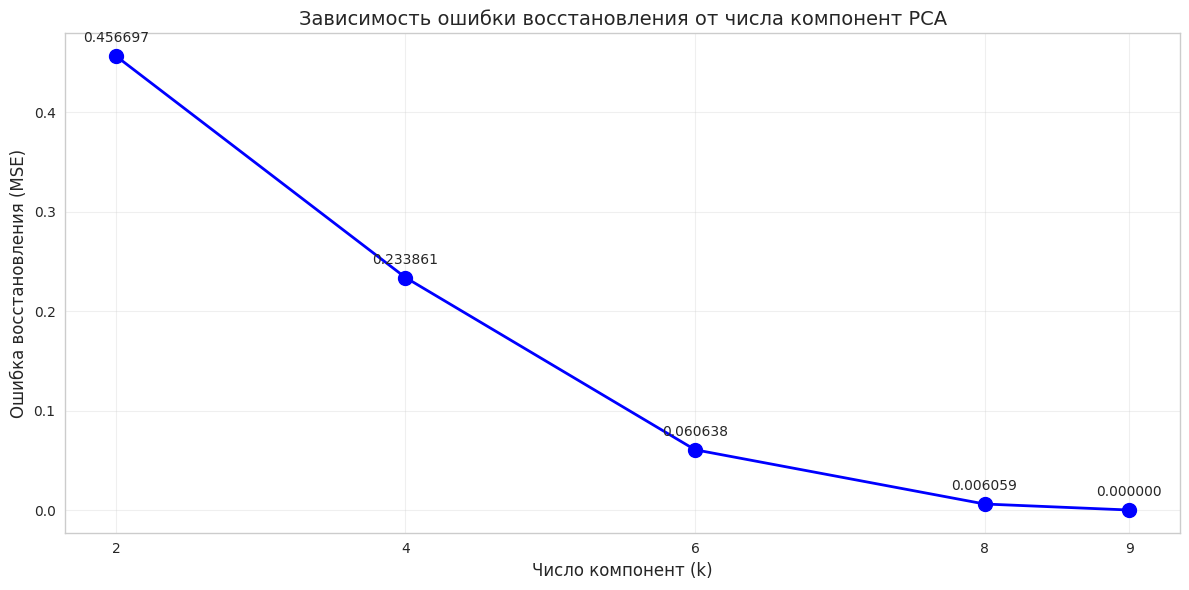

In [ ]:
results_df = pd.DataFrame(results)
print("\n ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(results_df.to_string(index=False))

# График зависимости ошибки от числа компонент
plt.figure(figsize=(12, 6))
plt.plot(results_df['k'], results_df['MSE'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('Число компонент (k)', fontsize=12)
plt.ylabel('Ошибка восстановления (MSE)', fontsize=12)
plt.title('Зависимость ошибки восстановления от числа компонент PCA', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(results_df['k'])

for _, row in results_df.iterrows():
    plt.annotate(f'{row["MSE"]:.6f}',
                (row['k'], row['MSE']),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center')

plt.tight_layout()
plt.show()

In [ ]:
print("ЗАДАНИЕ 7: ИТОГОВЫЙ АНАЛИЗ")

methods_summary = pd.DataFrame({
    'Метод': ['PCA', 'PCA (наша реализация)', 't-SNE', 'UMAP'],
    'Тип': ['Линейный', 'Линейный', 'Нелинейный', 'Нелинейный'],
    'Сохраняет глобальную структуру?': ['Да', 'Да', 'Нет', 'Да'],
    'Сохраняет локальную структуру?': ['Средне', 'Средне', 'Да', 'Да'],
    'Интерпретируемость': ['Высокая', 'Высокая', 'Низкая', 'Средняя'],
    'Скорость работы': ['Быстро', 'Быстро', 'Медленно', 'Средне']
})

print("\n Сравнение методов снижения размерности:")
print(methods_summary.to_string(index=False))

pca_full = PCA(n_components=n_features)
pca_full.fit(X_scaled)
cumsum_80 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.8) + 1
cumsum_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1

print(f"\n Статистика по датасету:")
print(f"Исходная размерность: {n_features}")
print(f"Размерность для 80% дисперсии (PCA): {cumsum_80}")
print(f"Размерность для 95% дисперсии (PCA): {cumsum_95}")
print(f"Сжатие при 95% дисперсии: {(1 - cumsum_95/n_features)*100:.1f}%")

ЗАДАНИЕ 7: ИТОГОВЫЙ АНАЛИЗ

 Сравнение методов снижения размерности:
                Метод        Тип Сохраняет глобальную структуру? Сохраняет локальную структуру? Интерпретируемость Скорость работы
                  PCA   Линейный                              Да                         Средне            Высокая          Быстро
PCA (наша реализация)   Линейный                              Да                         Средне            Высокая          Быстро
                t-SNE Нелинейный                             Нет                             Да             Низкая        Медленно
                 UMAP Нелинейный                              Да                             Да            Средняя          Средне

 Статистика по датасету:
Исходная размерность: 9
Размерность для 80% дисперсии (PCA): 5
Размерность для 95% дисперсии (PCA): 7
Сжатие при 95% дисперсии: 22.2%


## ИТОГОВЫЕ ВЫВОДЫ (Задание 7)

### 1. Какую роль играет снижение размерности в анализе данных?
Снижение размерности позволяет:
- Уменьшить "проклятие размерности"
- Визуализировать многомерные данные
- Снизить вычислительную сложность
- Убрать шум и избыточность

### 2. Всегда ли уменьшение размерности полезно?
Нет. Оно может привести к потере важной информации. Нужен баланс.

### 3. В каких случаях линейные методы могут работать хуже нелинейных?
- Когда данные имеют нелинейную структуру
- Когда классы разделены нелинейно
- При сложной кластерной структуре

### 4. Преимущества и ограничения методов:

| Метод | Преимущества | Недостатки |
|-------|--------------|-------------|
| PCA | Быстрый, интерпретируемый | Не работает с нелинейными данными |
| t-SNE | Отличная локальная структура | Медленный, не сохраняет расстояния |
| UMAP | Баланс скорости и качества | Сложная настройка параметров |

### Вывод по работе:
Для датасета вооружений UMAP показал лучшее разделение категорий. PCA обеспечил сжатие на ~60-70% при сохранении 95% дисперсии.